# <font color='steelblue'> 290. Modelos de regresión logística</font>

**Material desarrollado por los [equipos de trabajo de IA4LEGOS](https://ia4legos.umh.es/)**


**Fecha última edición**: 10/05/2025

**Licencia**: <small><a rel="license" href="http://creativecommons.org/licenses/by-sa/4.0/"><img alt="Creative Commons License" style="border-width:0" src="https://i.creativecommons.org/l/by-sa/4.0/88x31.png" /></a><br /></small>

No olvides hacer una copia si deseas utilizarlo. Al usar estos contenidos, aceptas nuestros términos de uso y nuestra política de privacidad.

In [ ]:
#@title <font color="steelblue" size="+1"> Ejecutar configuración
# @markdown Para garantizar la funcionalidad completa de este cuaderno, ejecuta esta celda de código que carga las librerías básicas de Python para el análisis de datos y su representación gráfica.

# Librerías python
##################

# De sistema
from io import StringIO
import sys
# Matemáticas
import numpy as np
import math
# Análisis de datos
import pandas as pd
# Gráficas
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

# <font color="steelblue">Descripción del cuaderno</font>



**Descripción:** En este cuaderno se presentan los modelos de regresión logística que modelizan el comportamiento de variables respuesta de tipo categórico con dos o más niveles de respuesta, pero en cualquier caso con un número finito de niveles, respecto a un conjunto de predictoras de tipo numérico o categórico. En concreto se trata de modelizar la probabildidad de clasificación en cada una de las categorías de la respuesta, en función de las predictoras consideradas. Si el número de niveles de la respuesta es 2 hablamos de los modelos de regresión logística binaria o binomial, mientras que si el número es mayor que dos hablamos de los modelos de regresión logística multinomial.

Ambos modelos se basan en los denominados modelos lineales generalizados que modelizan una función de la respuesta de interés en téminos de un modelo lineal de los vistos en los cuadernos anteriores.

Ejemplificamos los modelos estudiados con bases de datos.

**Recomendaciones antes de usarlo:** Conocimientos básicos del lenguaje Python, conceptos básicos de probabilidad, análisis exploratorio de datos e inferencia estadística. Modelo de regresión lineal, modelo ANOVA y modelo ANCOVA.



# <font color="steelblue">Contenidos</font>

1. Modelo lineal generalizado
1. Modelo de regresión logística binomial
1. Ejercicios



#<font color="steelblue">1. Modelo lineal generalizado

Todos los modelos estudiados hasta ahora comparten los mismos supuestos teóricos: una respuesta numérica cuya distribución se asume a una normal, y unos predictores categóricos o numéricos, que relacionamos con la respuesta a través de un predictor lineal del modo
$$ Y = X \beta$$

Aunque este tipo de modelos abarcan un gran conjunto de situaciones experimentales, también es cierto que en algunos casos las hipótesis del modelo, en especial las referidas a normalidad de la respuesta o linealidad, no se cumplen.

¿Qué podemos hacer cuando nuestro objetivo es predecir el número de accidentes de tráfico en un cruce, o el número de habitantes que van a sufrir cierta enfermedad en una población de tamaño $n$, o el tiempo esperado de vida de una bombilla?

En estos ejemplos estamos considerando variables respuesta que, por concepto, se modelizan como Poisson (como el número de accidentes), o Binomial (como el número de afectados en una población limitada), o incluso distribuciones como la Gamma o la Exponencial,  
asimétrica y acotada por abajo en el cero (como los tiempos de vida).


Además, no siempre será asumible un predictor lineal para predecir la respuesta con las covariables explicativas disponibles. Sin ir más lejos, relacionar una respuesta binomial, poisson o incluso exponencial con un predictor lineal, no excluiría predicciones negativas que, per sé son inviables en estas distribuciones.

Son este tipo de situaciones las que motivan la introducción de un nuevo tipo de modelos que, como caso particular engloban los modelos lineales, estudiados en los temas anteriores.

Los modelos lineales generalizados, conocidos por sus siglas en inglés, GLM (*Generalized Linear Models*), tienen las siguientes caracterizaciones:

1. Las $n$ observaciones disponibles sobre la variable respuesta $Y$ son independientes y proceden de una misma  distribución dentro de la familia exponencial, donde la función de densidad o probabilidad se puede expresar como:

$$ f(y|\theta,\phi) = exp \left\{ \frac{y\theta-b(\theta)}{a(\phi)} +c(y,\phi)\right\}$$
>con $\theta$ el parámetro natural o canónico, $\phi$ el parámetro de dispersión o escala, y $a()$, $b()$ y $c()$ funciones específicas de cada distribución.

>Esta familia engloba las distribuciones gausiana (normal), gausiana inversa, gamma, exponencial, binomial, binomial negativa y Poisson, entre otras.

1. Existen un conjunto de variables potencialmente independientes, categóricas o numéricas, que definen una matriz de diseño $X$ de tamaño $n \times p$, a partir de $p-1$ predictores con los que pretendemos predecir la respuesta.

1. La predicción con las covariables se plantea de modo lineal, esto es, con una expresión lineal $\eta= X\beta$, pero que se relaciona con la respuesta esperada $\mu=E(Y)$ a través de una función de enlace llamada *link*, $g()$:
$$ g(E(Y)) = X'\beta  \ : \ g(\mu) = \eta, \text{ con } \mu=E(Y), \ \eta= X\beta.$$





## Estimación

Los métodos numéricos para resolver el ajuste por máxima verosimilitud generalmente no son lineales en los parámetros de interés $\beta_j$, por lo que surge la necesidad de utilizar métodos numéricos, como son:
- **Newton-Raphson**
$$\hat{\beta~}^{(r)} =  \hat{\beta~}^{(r-1)} - H^{-1}_{\hat{\beta~}^{(r-1)}} U_{\hat{\beta~}^{(r-1)}}$$

>con $H = \frac{\partial^2 l(\theta,\phi;y)}{\partial \beta_j \partial \beta_k}$

- **Scoring de Fisher**
$$\hat{\beta~}^{(r)} =  \hat{\beta~}^{(r-1)} + J^{-1}_{\hat{\beta~}^{(r-1)}} U_{\hat{\beta~}^{(r-1)}}$$

>con $J = -E(H).$

Cualquiera de estos procedimientos iterativos de búsqueda de los EMV es expresable en términos de un ajuste iterativo de mínimos cuadrados ponderados, lo que da lugar a la denominación del método de estimación como **ajuste por mínimos cuadrados ponderados iterados**.

Así mismo, será preciso estimar el parámetro de escala $\phi$, de modo que para derivar las estimaciones sobre los parámetros $\beta$ del modelo, se utilizará la distribución *T-Student*, con $\nu=n-p$ grados de libertad (realmente, los que se utilicen para estimar la escala):
$$\frac{\hat{\beta~}}{Var(\hat{\beta~})} \sim t_{n-p}$$





## Evaluación del ajuste

Se define como indicador de la bondad del ajuste de un GLM, el **estadístico de Wald**
$$WD = (\hat{\beta~}-\beta)' J (\hat{\beta~}-\beta)$$
que tiene como distribución asintótica una chi-cuadrado con $p$ grados de libertad, $\chi^2_p$, cuando el parámetro de escala $\phi$ es conocido,
y una distribución $F$ con $p$ y $n-p$ grados de libertad, $F_{p,n-p}$, cuando es preciso estimar el parámetro de escala


Este estadístico en los GLM viene a representar el papel que tiene el estadístico $F$ de bondad de ajuste en los modelos lineales que ya estudiamos. Si es significativo, esto es, si el p-valor asociado es inferior a 0.05, se rechaza que el modelo no explica la variabilidad de los datos, a favor, de que sí la explica significativamente.

Otro modo de testar la bondad del ajuste de un GLM es a través del estadístico **Deviance**, que se define a partir del estadístico del cociente de verosimilitudes,  con la diferencia entre la log-verosimilitud del modelo ajustado y la del modelo saturado, cuando se conoce el parámetro de escala $\phi$.
$$D= -2(l(\hat{~\theta},\phi;y)-l(\hat{\theta}_{sat},\phi;y))$$

El **modelo saturado** comparte la forma del modelo propuesto, pero utiliza en la estimación tantos parámetros como datos ($p=n$), de modo que proporciona un ajuste perfecto a los datos, sin grados de libertad para los residuos.

La expresión más habitual para el estadístico Deviance, salvando el parámetro de escala, que suele ser desconocido, es:
$$D= 2 \sum_{i=1}^n y_i (\hat{\theta~}_{sat}-\hat{\theta~})- b(\hat{\theta~}_{sat})+b(\hat{\theta~}) $$

Cuando un ajuste es bueno, se va a aproximar al modelo saturado, esto es, a un modelo que predice perfectamente las observaciones, por lo que su deviance será pequeña. Así pues, valores pequeños de la deviance habla a favor de un buen ajuste con el modelo utilizado.






## Comparación de modelos

Para comparar dos modelos anidados $M_1 \subset M_2$, en los que las $p_1$ columnas de la matriz de diseño de $M_1$ están contenidas en las $p_2$ columnas de la matriz de diseño de $M_2$, $p_2>p_1$, se plantea el contraste que postula el modelo más simple en la hipótesis nula, y el más complejo en la alternativa, $H_0: M_1$ versus $H_1: M_2$.

Para resolverlo, se utilizan las respectivas deviances, $D_1$ y $D_2$ y la distribución de su diferencia, que tiene una distribución proporcional a una chi-cuadrado con $p_2-p_1$ grados de libertad cuando se conoce el parámetro de escala.

$$ \frac{D_1-D_2}{\phi} \sim \chi^2_{p_2-p_1}$$

y una distribución F cuando el parámetro de escala es desconocido y se ha de estimar:
$$ \frac{(D_1-D_2)/(p_2-p_1)}{D_2/(n-p_2)}  \sim F_{p_2-p_1, n-p_2}$$


Otros estadísticos con los que realizar la comparación de modelos, considerando tanto la variabilidad explicada como la penalización por complejidad, son:

- **$C_p$ de Mallows**:
$$ C_p = \frac{RSS_p}{s^2} - n +2p $$
donde $RSS_p$ es la suma de cuadrados residual para el modelo con $p$ parámetros estimados, y $s^2$ es un estimador insesgado de la varianza, obtenido como la suma de cuadrados residual media.
- **AIC**, que es una versión del estadístico $C_p$ en términos de verosimilitud, y que se expresa pues, en función de la deviance y del EMV del parámetro de escala:
$$ AIC = D + 2p\hat{~\phi} $$

Se prefieren pues, modelos con menor valor para el índice de calidad ($C_p$ o AIC).

Como siempre, para la selección de variables podemos optar por una estrategia de búsqueda paso a paso (*stepwise*), hacia adelante (*forward*) o hacia atrás (*backward*), con cualesquiera de los criterios de comparación expuestos.

Expuestos ya los fundamentos de los modelos lineales generalizados, pasamos a describir de modo detallado, cómo ajustar dos modelos GLM que son muy habituales en la práctica:
- el modelo de regresión logística para respuesta binaria
- el modelo de regresión logística para respuesta multinomial.

# <font color="steelblue">2. Modelo de regresión logística Binomial</font>

Comenzamos nuestro estudio con el GLM más sencillo, donde la variable respuesta de tipo categórica con solo dos categorías o niveles. Es la típica variable 'éxito-fracaso' o '0/1', que se utiliza para registrar si se ha dado un evento o no (exitus de un paciente.

Consideramos pues, que nuestros datos consisten en una muestra de tamaño $n$ donde pueden provenir:

- de registros individualizados de una variable binaria, $Y$, con respuestas posibles 0 ("fracaso") y 1 ("éxito"), de modo que las observaciones disponibles son $y_1,...,y_n$ independientes, distribuídas con distribuciones Bernouilli $y_i\sim Br(\pi_i)$, donde el parámetro de interés o canónico viene representado por la respuesta esperada, que coincide con la probabilidad de éxito:

$$E(Y_i)=\pi_i:  \text{ con } Pr(Y_i = 1) = \pi_i, Pr(Y_i = 0) = 1 - \pi_i$$

- de registros agrupados con el número de éxitos en grupos de sujetos, y por lo tanto modelizables como respuestas binomiales, $Z_i\sim Bin(n_i,\pi_i)$, y donde de nuevo el parámetro de interés es la probabilidad de éxito $\pi_i$, involucrado en el valor esperado de la respuesta:

$$E(Z_i)=n_i\pi_i; \ \ i=1,...,n$$

El objetivo pues, de un modelo logístico, será el de explicar y predecir la probabilidad de éxito $\pi_i$ en función de un conjunto de variables predictoras disponibles.


Se cuenta entonces siempre en este tipo de problemas, con un conjunto de $p-1$ predictoras $\{x_1, x_2,..., x_{p-1}\}$, de tipo numérico o categórico (*dummies*), que definen una matriz de diseño $X$ de dimensión $n \times p$, potencialmente relacionadas con la respuesta esperada,  y por lo tanto con la probabilidad de éxito. Puesto que el parámetro de interés, la probabilidad de éxito, está acotado en el rango $[0,1]$, para poderlo relacionar con un predictor lineal dado por $X\beta$, es preciso utilizar una función, como la **función logística**, que proyecta el rango $[0,1]$ en la recta real $[-\infty,+\infty]$, y que tiene la siguiente expresión analítica:
$$g(\pi)=logit(\pi) = log(\pi/(1-\pi))$$

La función logística actuará pues como **función link**, para relacionar la respuesta esperada (en realidad la probabilidad de éxito) con el predictor lineal:

$$ logit(\pi_i) = \eta_i =  \beta_0 + \beta_1 X_{i1}+ ... + \beta_p X_{i,p-1}=x_i\beta,$$

donde $x_i$ representa la i-ésima fila de la matriz de diseño $X$ y $\eta=X\beta$ es el predictor lineal.

Esta expresión del problema de predicción a modo de modelo lineal nos permitirá obtener las estimaciones de los coeficientes $\beta$, con los que podremos recuperar la estimación del parámetro de interés, y en particular de las probabilidades de éxito y fracaso, con:

$$\hat{\pi_i} = \frac{e^{x_i\hat{\beta}}}{1+e^{x_i\hat{\beta}}}, \ \ 1- \hat{\pi_i} = \frac{1}{1+e^{x_i\hat{\beta}}}.$$

Trabajamos a continuación sobre dos ejemplos que plantean las dos posibilidades de respuesta planteadas: datos individualizados (respuesta Bernoilli) y datos agrupados (respuesta binomial).

## Ejemplo 1. Kyphosis

En este banco de datos aparecen los datos de 81 niños que fueron intervenidos quirúrgicamente para corregirles problemas en la columna vertebral. La variable binaria `kyphosis` indica la presencia (1) o ausencia (0) de una deformidad postoperatoria en la columna, denominada cifosis. Las otras tres variables son `Age`, edad del niño en meses, `Number`, número de vértebras intervenidas en la operación, y `Start`, que identifica la primera vértebra involucrada en la operación (desde la cabeza hacia abajo). Es de interés en el análisis investigar cómo están relacionadas dichas variables a la hora de predecir la incidencia de la cifosis en el postoperatorio. En este caso todas las variables predictoras son de tipo numérico.

Puesto que los datos vienen individualizados para cada paciente, la variable respuesta se puede representar mediante una Bernouilli, o lo que es lo mismo, $Y_i \sim Bi(n = 1, \pi_i)$,  con $\pi_i$ la probabilidad de que el sujeto $i$ sufra una deformidad postoperatoria.

El objetivo de la modelización es predecir la probabilidad de cifosis en función de la edad, el número de vértebra y la edad de un paciente pediátrico mediante el modelo logit:

$$logit(\pi) = \theta + \alpha \cdot Age + \beta \cdot Number + \delta \cdot Start.$$

Cargamos los datos correspondientes:

In [ ]:
# DATOS KYPHOSIS
kyphosis = [0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1,
0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1,
0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0]
#kyphosis = ["absent", "absent", "present", "absent", "absent", "absent", "absent", "absent", "absent", "present",
#            "present", "absent", "absent", "absent", "absent", "absent", "absent", "absent", "absent", "absent", "absent",
#            "present", "present", "absent", "present", "absent", "absent", "absent", "absent", "absent", "absent", "absent",
#            "absent", "absent", "absent", "absent", "absent", "present", "absent", "present", "present", "absent", "absent",
#            "absent", "absent", "present", "absent", "absent", "present", "absent", "absent", "absent", "present", "absent",
#            "absent", "absent", "absent", "present", "absent", "absent", "present", "present", "absent", "absent", "absent",
#            "absent", "absent", "absent", "absent", "absent", "absent", "absent", "absent", "absent", "absent", "absent",
#            "present", "absent", "absent", "present", "absent"]
age = [71, 158, 128, 2, 1, 1, 61, 37, 113, 59, 82, 148, 18, 1, 168, 1, 78, 175, 80, 27, 22, 105, 96, 131,
         15, 9, 8, 100, 4, 151, 31, 125, 130, 112, 140, 93, 1, 52, 20, 91, 73, 35, 143, 61, 97, 139, 136, 131,
         121, 177, 68, 9, 139, 2, 140, 72, 2, 120, 51, 102, 130, 114, 81, 118, 118, 17, 195, 159, 18, 15, 158,
         127, 87, 206, 11, 178, 157, 26, 120, 42, 36]
number = [3, 3, 4, 5, 4, 2, 2, 3, 2, 6, 5, 3, 5, 4, 3, 3, 6, 5, 5, 4, 2, 6, 3, 2, 7, 5, 3, 3, 3, 2, 3, 2, 5, 3,
            5, 3, 3, 5, 6, 5, 5, 3, 9, 4, 3, 3, 4, 5, 3, 2, 5, 2, 10, 2, 4, 5, 3, 5, 7, 3, 4, 7, 4, 3, 4, 4, 2, 4,
            4, 5, 5, 4, 4, 4, 3, 4, 3, 7, 2, 7, 4]
start = [5, 14, 5, 1, 15, 16, 17, 16, 16, 12, 14, 16, 2, 12, 18, 16, 15, 13, 16, 9, 16, 5, 12, 3, 2, 13, 6, 14,
           16, 16, 16, 11, 13, 16, 11, 16, 9, 6, 9, 12, 1, 13, 3, 1, 16, 10, 15, 13, 3, 14, 10, 17, 6, 17, 15, 15,
           13, 8, 9, 13, 1, 8, 1, 16, 16, 10, 17, 13, 11, 16, 14, 12, 16, 10, 15, 15, 13, 13, 13, 6, 13]
Kyphosis = pd.DataFrame({"kyphosis": kyphosis, "age": age, "number": number, "start": start})
Kyphosis.head(5)

,kyphosis,age,number,start
0,0,71,3,5
1,0,158,3,14
2,1,128,4,5
3,0,2,5,1
4,0,1,4,15


Representamos ahora la respuesta frente a cada una de las predictoras. Puesto que todas ellas son de tipo numérico, utilizamos gráficos de cajas para diferenciar por la variable respuesta binaria:

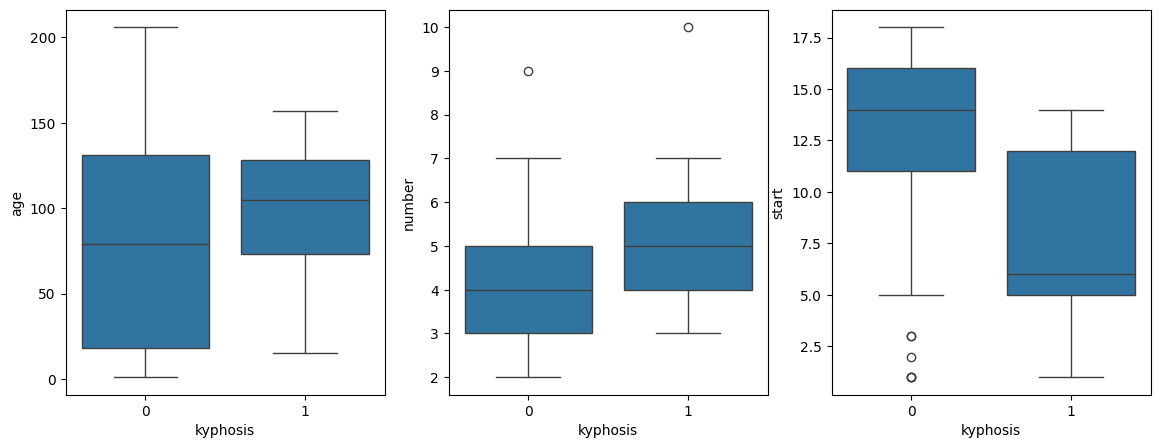

In [ ]:
# Representación gráfica de Kyphosis
f, ax = plt.subplots(nrows=1, ncols=3, figsize=(14, 5))
sns.boxplot(Kyphosis, x = "kyphosis", y = "age", ax=ax[0])
sns.boxplot(Kyphosis, x = "kyphosis", y = "number", ax=ax[1])
sns.boxplot(Kyphosis, x = "kyphosis", y = "start", ax=ax[2])
plt.show()

En cada uno de los gráficos podemos ver el efecto de cada predictora sobre la presencia o ausencia de malformación. La variable `Start` es la que parece estar asociada a diferencias mayores en la presencia de malformación: la cifosis está asociada a vértebras de inicio más próximas a la cabeza. También parece que la incidencia está asociada a edades mayores y a un mayor número de vértebras involucradas.

## Ejemplo 2. Dosis-respuesta

Los estudios de dosis-respuesta son muy habituales en ensayos clínicos en los que se trata de valorar la eficacia de cierto tratamiento, y se registra, para diferentes dosis, la eficacia conseguida, evaluada a partir del número/ratio de pacientes que han tenido un efecto positivo.

Collet (1991) presenta un experimento sobre la toxicidad, a distintas dosis (en microgramos), del piretroide trans-cipemetrín, en los capullos de gusano del tabaco. Se había comenzado a detectar resistencia de esas polillas a dicho tóxico, y se pretendía verificar. El experimento consistía en exponer, durante tres días y a distintas dosis de tóxico, a series de 20 polillas de cada sexo (`total`). Se anotó el número de polillas muertas en cada serie (`dead`). El objetivo es pues investigar la resistencia al tóxico, en función del sexo de la polilla (`sex`) y de la dosis (`dosis`). También se desea determinar la dosis a la cual es posible garantizar el exterminio de al menos el 50% de los insectos.

En este caso tenemos un modelo $Y_i \sim Bi(n = 20, \pi_i)$, con $\pi_i$ la **probabilidad de morir (exitus)**, para una polilla en la combinación $i$ de dosis-sexo.

El modelo que se propone es estimar la probabilidad de exterminio en función de la dosis administrada, teniendo en cuenta el sexo de la polilla. Puesto que habitualmente se utiliza el logaritmo de la dosis para linealizar la relación con la proporción de muertos, el modelo planteado sería:

$$logit(\pi) = \theta + \alpha^{\text{Sex}}  + (\beta + \delta^{\text{Sex}}) \cdot LDosis,$$

considerando un posible efecto diferencial del sexo en la relación dosis-exitus.

Cargamos y representamos los datos para este experimento a continuación.

In [ ]:
# Banco de datos original
Dosis = pd.read_csv('https://goo.gl/w23RGz')
Dosis.head(5)

,sex,dosis,total,dead
0,M,1,20,1
1,M,2,20,4
2,M,4,20,9
3,M,8,20,13
4,M,16,20,18


Utilizamos la variable `logdosis`, y también calculamos el ratio de muertos, `dead_ratio`, y su logit, `logit_ratio`. Representamos estas dos variables de ratio en función de `logdosis`.

In [ ]:
# log de dosis
Dosis['logdosis'] = np.log(Dosis['dosis'])
# ratio de muertos
Dosis['dead_ratio'] = Dosis['dead']/(Dosis['total'])
# logit del ratio de muertos
from scipy.special import logit
Dosis["logit_ratio"] = logit(Dosis["dead_ratio"])
# banco de datos completo
Dosis.head(5)

,sex,dosis,total,dead,logdosis,dead_ratio,logit_ratio
0,M,1,20,1,0.000000,0.05,-2.944439
1,M,2,20,4,0.693147,0.20,-1.386294
2,M,4,20,9,1.386294,0.45,-0.200671
3,M,8,20,13,2.079442,0.65,0.619039
4,M,16,20,18,2.772589,0.90,2.197225


Representamos ahora el ratio de muertos y su logit, en función del sexo, la dosis, y su logaritmo.

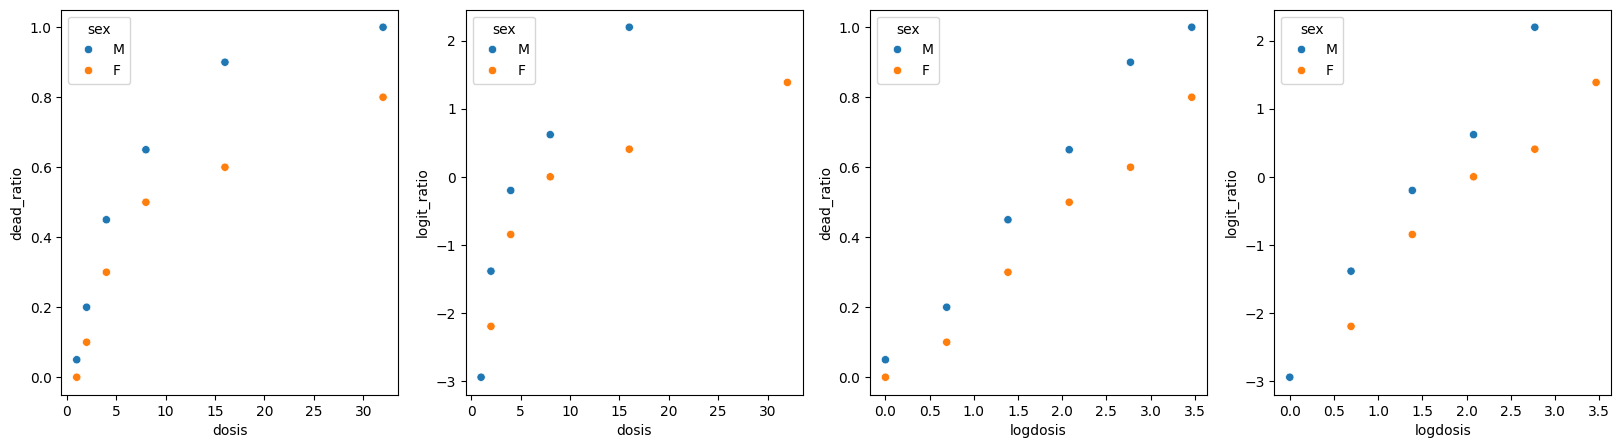

In [ ]:
# Representación del ratio de muertos versus logdosis
f, ax = plt.subplots(figsize=(20,5),ncols=4,nrows=1)
sns.scatterplot(Dosis, x = "dosis", y = "dead_ratio", hue = "sex",ax=ax[0])
sns.scatterplot(Dosis, x = "dosis", y = "logit_ratio", hue = "sex",ax=ax[1])
sns.scatterplot(Dosis, x = "logdosis", y = "dead_ratio", hue = "sex",ax=ax[2])
sns.scatterplot(Dosis, x = "logdosis", y = "logit_ratio", hue = "sex",ax=ax[3]);

Es clara la tendencia lineal creciente entre `logdosis` y el ratio de muertos `dead_ratio`. Se observa además, que para una misma dosis, el ratio de hembras muertas es menor que el de machos (al quedar todos los puntos por debajo).

## Interpretación de los parámetros

En este tipo de modelos hay que tener en cuenta que la relación entre  la probabilidad y las predictoras no es lineal, de modo que los coeficientes de regresión  no se pueden interpretar con el cambio que provoca en la probabilidad el incremento en una unidad de la predictora. Por ese motivo se consideran otro tipo de parámetros extraídos a partir de los coeficientes del modelo, que nos permiten realizar una interpretación práctica más sencilla.

Partimos de la definición de **odds** como el cociente de la probabilidad de que se dé un evento (digamos, éxito) frente a que no se dé, es decir, la ventaja de ocurrencia frente a no ocurrencia:
$$ODDS=\frac{\pi}{1-\pi}.$$

Supongamos un modelo logístico sencillo, con una única variable predictora $x$, de modo que el predictor lineal, equivalente al logaritmo del odds en $x$, en  se expresa con:
$$\eta (x)= log(odds(x)) = \theta + \beta x$$

El cambio del predictor en una unidad ($x \rightarrow x+1$) supone un cambio en el predictor lineal de $\beta$, o lo que es lo mismo, un cambio en el **log-odds**:
$$ \eta(x+1)-\eta(x)= \beta=log\left(\frac{odds(x+1)}{odds(x)}\right)$$
surge así el logaritmo del **odds ratio** (OR), que representa la variación de riesgo (del evento de interés) provocada por un incremento en una unidad en la predictora:
$$\text{OR}(x,x+1)=\frac{odds(x+1)}{odds(x)}=\frac{\pi(x+1)/(1-\pi(x+1))}{\pi(x)/(1-\pi(x))}=exp(\beta)$$

Así, la interpretación del coeficiente $\beta$ de una variable regresora es directa:

* si $\beta$ es mayor que 0, o lo que es lo mismo, $OR=exp(\beta)>1$, incrementar la variable $x$ en una unidad incrementa el riesgo del evento asociado al éxito;
* si $\beta$ es menor que 0, es decir, $OR=exp(\beta)<1$, incrementar la variable $x$ en una unidad reduce el riesgo del evento asociado al éxito.

Por ejemplo, un odds ratio de 3 nos dice que hay tres veces más riesgo cuando aumenta en una unidad el valor de la predictora, mientras que un odds ratio de 0.5 indica que el riesgo disminuye a la mitad cuando aumenta en una unidad el valor de la predictora.

## Ajuste y evaluación con Python


Para realizar el proceso de estimación de este tipo de modelos en Python utilizamos la función [`glm`](https://www.statsmodels.org/stable/glm.html) del módulo `statsmodels.formula.api`.


Cuando tenemos variables predictoras numéricas, es recomendable su estandarización para entender mejor el comportamiento de las predictoras en el modelo predictivo (todas en la misma escala), y mejorar la convergencia del algoritmo de estimación.

Antes de proceder con el ajuste, es recomendable cargar las funciones complementarias a continuación, que nos facilitan la estandarización, la carga de las métricas de validación de la librería `Scikit-Learn`, el test de la Deviance y el cálculo del AIC y del BIC en estos modelos.

In [ ]:
# @title Funciones complementarias para el ajuste: estandarización, bondad de ajuste y validación
# Ajuste del modelo
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Evaluación
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import roc_curve, roc_auc_score, auc

# Función para estandarizar variables de una base de datos
def estandarizar(df, lista_variables):
  """
  Estandariza las variables especificadas en un dataframe.

  Parámetros:
    - df: dataframe con variables numéricas a estandarizar
    - lista_variables: lista con los nombres de las variables numéricas a estandarizar
  """
  # Recorremos la lista con las variables numéricas con un bucle for
  for i in lista_variables:
    # para cada variable "i", le añadimos el sufijo _est.
    df[f"{i}_est"] = (df[i] - df[i].mean())/df[i].std()

# Función para bondad de ajuste en modelos binomiales
def gof_binom(mod, datos):

    """
    Evalúa el test de chi-cuadrado correspondiente a un modelo glm binomial.

    Parameters
    ----------
    mod:
    datos: pdDataFrame
        Conjunto de datos sobre los que evaluar los modelos

    Returns
    -------
    pvalor:
        1-pvalor del test ji cuadrado de la deviance residual del modelo para gof.
    """

    from scipy import stats

    ajuste = smf.glm(mod, data = datos, family=sm.families.Binomial()).fit()
    valor = 1-stats.chi2.pdf(ajuste.deviance, ajuste.df_resid)
    return valor

# Función para evaluación de modelos con AIC o BIC
def anova_selection_glm(mod, metrica, datos):

    """
    Evalúa la métrica considerada para un conjunto de modelos.

    Parameters
    ----------
    mod:
    metrica: str
        Métrica utilizada para seleccionar el modelo. Debe ser una de las
        siguientes opciones: 'aic', 'bic_deviance'.
    datos: pdDataFrame
        Conjunto de datos sobre los que evaluar los modelos

    Returns
    -------
    modelo: list
        modelo con el mejor valor de la métrica.
    """

    valores = []

    if metrica == 'aic':
      for i in range(len(mod)):
        ajuste = smf.glm(mod[i], data = datos, family=sm.families.Binomial()).fit()
        valores.append(round(getattr(ajuste, metrica),4))
        pos = valores.index(min(valores))
    if metrica == 'bic_deviance':
      for i in range(len(mod)):
        ajuste = smf.glm(mod[i], data = datos, family=sm.families.Binomial()).fit()
        valores.append(round(getattr(ajuste, metrica),4))
        pos = valores.index(min(valores))

    return mod[pos]

La sintaxis básica para ajustar el modelo logístico es la siguiente, donde la respuesta $y$ contiene:
- la variable de 0/1 en datos Bernouilli;
- la proporción de éxitos (1) en datos binomiales.

Las variables predictoras se introducen en el modelo ya estandarizadas.

```
# Cargamos las funciones previas para el ajuste logístico
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Ajuste del modelo
fit = smf.glm('y ~ x1 + x2 + ...',
                      data = datos,
                      family=sm.families.Binomial()).fit()
# Descriptivo del ajuste
print(fit.summary())

# Probabilidades predichas
prob_pred = fit.predict()

# Clasificación predicha
clasif_pred = 1*prob_pred>0.5

# Predicción de nuevas observaciones
fit.predict(newdata([['x1','x2',...]])

# MATRIZ DE CONFUSIÓN
target_names # lista con valores de la respuesta (éxito/fracaso)
labels_names # lista con etiquetas de la respuesta

# Matriz de confusión
cm = confusion_matrix(datos['y'], clasif_pred, labels=labels_names)
# Solución gráfica
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels=target_names)
disp.plot(cmap ='Blues');

# Informe completo de clasificación (métricas de clasificación)
print(classification_report(datos['y'], clasif_pred, labels=labels_names, target_names=target_names))
# exactitud
print('Exactitud del ajuste:',round(accuracy_score(datos['y'], clasif_pred),4))


# Curva ROC
fpr, tpr, thresholds = roc_curve(datos['y'], clasif_pred);
sns.lineplot(x=fpr, y=tpr);
sns.lineplot(x=[0, 1], y=[0, 1]);
# Área bajo la curva
round(roc_auc_score(datos['y'], clasif_pred),3)
```


### Ejemplo 1. Kyphosis

En primer lugar ajustamos el modelo con todas las predictoras disponibles. Como todas son numéricas no hay que incluir ningún tipo de interacción pero . Como tenemos la información individual de cada sujeto podemos modelizar directamente la variable 0-1.

In [ ]:
# Identificamos las variables a estandarizar
var_num = ['age', 'number', 'start']
# Estandarizamos
estandarizar(Kyphosis, var_num)
# Ajustamos el modelo con las variables estandarizadas
fit_kyphosis = smf.glm('kyphosis ~ age_est + number_est + start_est',
                      data = Kyphosis, family = sm.families.Binomial()).fit()
print(fit_kyphosis.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:               kyphosis   No. Observations:                   81
Model:                            GLM   Df Residuals:                       77
Model Family:                Binomial   Df Model:                            3
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -30.690
Date:                Fri, 20 Dec 2024   Deviance:                       61.380
Time:                        12:43:13   Pearson chi2:                     70.3
No. Iterations:                     6   Pseudo R-squ. (CS):             0.2365
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.8335      0.395     -4.647      0.0

Si $\pi$ denota la probabilidad de sufrir de una malformación post-operatoria, la ecuación del modelo viene dada (en función de las variables estandarizadas, identificadas por el subíndice $_e$) por:

$$log\left(\frac{\pi}{1-\pi}\right) = -1.8335 + 0.6351 \cdot age_e+0.6649 \cdot number_e-1.0086 \cdot start_e$$

Se puede ver que la variable más influyente es `start` y la que menos influyente es `age`.  Para interpretar adecuadamente el efecto de cada predictora, obtenemos los odds ratio asociados a cada una ($exp(\beta)$).

In [ ]:
# Odds ratio
pd.DataFrame(np.exp(fit_kyphosis.params), columns=['OR'])

,OR
Intercept,0.159859
age_est,1.887225
number_est,1.944368
start_est,0.364734


En términos de los odds ratios podemos ver que el riesgo de sufrir una malformación aumenta 1.88 y 1.94 respectivamente, al aumentar en una unidad las variables `Age` y `Number` (sufrirla es 1.88 veces más probable que no sufrirla).  Con la variable `Start` podemos ver que el odds-ratio queda por debajo de 1, esto es, la probabilidad de sufrir la malformación es 0.36 veces inferior a la de no sufrirla cuando se inicia la operación en una vértebra situada más abajo en la columna vertebral.

Evaluamos la bondad de ajuste del modelo con la deviance.

In [ ]:
# Bondad de ajuste con la deviance
gof_binom('kyphosis ~ age_est + number_est + start_est', Kyphosis)

0.9839434567171361

Dado que el pvalor asociado a la deviance es superior a 0.05, no rechazamos el modelo propuesto, de modo que lo conservamos para explicar los datos con eficacia.

A continuación procedemos con la selección del mejor modelo utilizando el criterio AIC. Para este proceso es necesario definir todos los posibles modelos:

In [ ]:
# Combinación de modelos
modelos = [
    'kyphosis ~ age_est + number_est + start_est',
    'kyphosis ~ age_est + number_est ',
    'kyphosis ~ age_est + start_est',
    'kyphosis ~ number_est + start_est',
    'kyphosis ~ age_est',
    'kyphosis ~ number_est',
    'kyphosis ~ start_est',
    'kyphosis ~ 1'
]
# Evaluación
anova_selection_glm(modelos, 'aic', Kyphosis)

'kyphosis ~ age_est + number_est + start_est'

El modelo final seleccionado contiene todas las predictoras posibles: no se excluye ninguna.

Proseguimos la evaluación del modelo con las métricas de clasificación, a partir de las predicciones del modelo (probabilidades) y la clasificación que generan (utilizando como regla de salto el valor 0.5). Calculamos estas predicciones y la matriz de confusión.

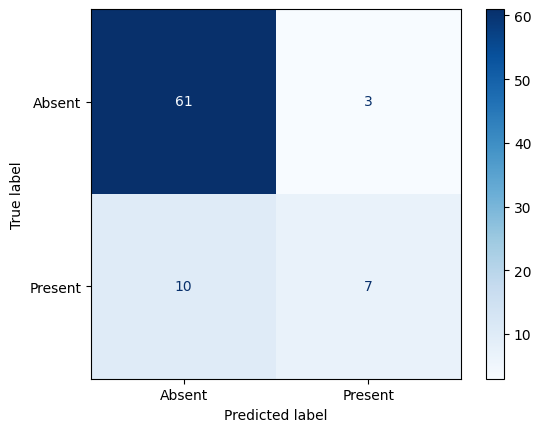

In [ ]:
# Probabilidad predicha con el modelo
prob_pred = fit_kyphosis.predict()
# Clasificación predicha
clasif_pred = 1*prob_pred>0.5

# MATRIZ DE CONFUSIÓN
target_names = ['Absent', 'Present']
labels_names = [0,1]
# Matriz de confusión
cm = confusion_matrix(Kyphosis['kyphosis'], clasif_pred,
                      labels = labels_names)
# Solución gráfica
disp = ConfusionMatrixDisplay(confusion_matrix = cm,
                              display_labels = target_names)
disp.plot(cmap ='Blues');

Apreciamos que en 68 casos (en la diagonal principal: 61+7), la clasificación proporcionada por el modelo coincide con el valor real observado. Existen 13 casos donde no coincide se da un fallo, con una incidencia especial de 10 en los falsos negativos: se predicen sin malformación (`Absent`) cuando realmente sí la tienen (`Present`).

Mostramos ahora el informe de clasificación, que nos permite entender mejor el proceso de clasificación.

In [ ]:
# Informe completo de clasificación
print(classification_report(Kyphosis['kyphosis'], clasif_pred,
                            labels = labels_names, target_names = target_names))
# exactitud
print('Exactitud del ajuste:',round(accuracy_score(Kyphosis['kyphosis'], clasif_pred),4))


              precision    recall  f1-score   support

      Absent       0.86      0.95      0.90        64
     Present       0.70      0.41      0.52        17

    accuracy                           0.84        81
   macro avg       0.78      0.68      0.71        81
weighted avg       0.83      0.84      0.82        81

Exactitud del ajuste: 0.8395


En la tabla de reporte, tenemos las columnas `precision` (precisión), `recall`(recuerdo) y `f1-score`, en cada uno de los niveles de la respuesta en la parte superior de la tabla, y de modo global en la parte inferior, con el promedio ` macro avg` y el promedio ponderado por los tamaños (`support`), en `weighted avg`. Podemos ver que el 86% de las observaciones identificadaos como `Absent` son clasificadas correctamente por el modelo (`precision`), pero solo el 70% de la clase `Present`, lo que supone un 83% de clasificación correcta promedio. Las medidas de recuerdo y f1-score salen bien para las observaciones sin malformación, pero bastante mal para las observaciones con malformación, si bien las medidas promedio quedan también en torno al 83%.  La exactitud (porcentaje de observaciones clasificadas correctamente) es del 83.95%.

Los resultados obtenidos muestran que el modelo es bueno pero no excelente en el proceso de clasificación de los sujetos que sufren malformación.

Para finalizar la evaluación de la clasificación obtenida vamos a obtener la curva ROC y el AUC. En primer lugar vamos como obtener la curva ROC:

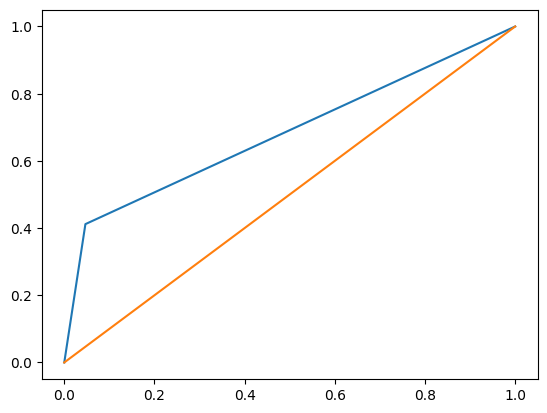

In [ ]:
# Calculamos y representamos curva ROC
fpr, tpr, thresholds = roc_curve(Kyphosis['kyphosis'], clasif_pred);
sns.lineplot(x=fpr, y=tpr);
sns.lineplot(x=[0, 1], y=[0, 1]);

Observamos que la curva ROC queda muy próxima a la diagonal, indicando que el modelo como herramienta de clasificación no es muy adecuado. Para finalizar obtenemos el AUC correspondiente.

In [ ]:
# Área bajo la curva
round(roc_auc_score(Kyphosis['kyphosis'], clasif_pred),3)

0.682

Constatamos numéricamente lo que ya apreciábamos en la curva: el AUC queda demasiado próximo a 0.5, revelando el ineficiente comportamiento del modelo como herramienta de clasificación.

### Ejemplo 2. Dosis-respuesta

En este caso tenemos una predictora numérica y otra categórica, por lo que el modelo completo incluye los efectos individuales de cada una de ellas y la correspondiente interacción. En este caso no es necesario estandarizar al tener solo una predictora numérica. Modelizamos la probabilidad de muerte, utilizando como variable respuesta el ratio de muertos.



In [ ]:
Dosis.head()

,sex,dosis,total,dead,logdosis,dead_ratio,logit_ratio
0,M,1,20,1,0.000000,0.05,-2.944439
1,M,2,20,4,0.693147,0.20,-1.386294
2,M,4,20,9,1.386294,0.45,-0.200671
3,M,8,20,13,2.079442,0.65,0.619039
4,M,16,20,18,2.772589,0.90,2.197225


In [ ]:
# Ajustamos el modelo
fit_dosis = smf.glm('dead_ratio ~ logdosis + sex + logdosis:sex',
                      data = Dosis, family=sm.families.Binomial()).fit()
print(fit_dosis.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:             dead_ratio   No. Observations:                   12
Model:                            GLM   Df Residuals:                        8
Model Family:                Binomial   Df Model:                            3
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -3.6117
Date:                Thu, 19 Dec 2024   Deviance:                      0.24969
Time:                        18:09:16   Pearson chi2:                    0.175
No. Iterations:                     5   Pseudo R-squ. (CS):             0.3932
Covariance Type:            nonrobust                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            -2.9935      2.47

El modelo ajustado viene dado por las expresiones siguientes (una ecuación por cada sexo):

$$\begin{array}{rll}
\text{Female: } & log\left(\frac{\pi_F}{1-\pi_F}\right) = & -2.9935 + 1.3071 \cdot logdosis\\
\text{Male: } & log\left(\frac{\pi_M}{1-\pi_M}\right) = &  -2.8185 + 1.8162 \cdot logdosis\\
\end{array}$$

Antes de profundizar en la solución procedemos con la selección del mejor modelo, planteando todas las alternativas y eligiendo con el AIC.

In [ ]:
# Combinación de modelos
modelos = [
    'dead_ratio ~ sex + logdosis + logdosis:sex',
    'dead_ratio ~ sex + logdosis',
    'dead_ratio ~ logdosis',
    'dead_ratio ~ sex',
    'dead_ratio ~ 1'
]
# Comparación y selección de modelos
anova_selection_glm(modelos, 'aic', Dosis)

'dead_ratio ~ logdosis'

El modelo seleccionado solo contiene la predictora `logdosis`, y descarta la variable `sex`, y por lo tanto su interacción con ella.

Reajustamos el modelo con logdosis.

In [ ]:
# Ajustamos el modelo
fit_dosis = smf.glm('dead_ratio ~ logdosis',
                      data = Dosis, family=sm.families.Binomial()).fit()
print(fit_dosis.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:             dead_ratio   No. Observations:                   12
Model:                            GLM   Df Residuals:                       10
Model Family:                Binomial   Df Model:                            1
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -3.9114
Date:                Thu, 19 Dec 2024   Deviance:                      0.84920
Time:                        18:09:38   Pearson chi2:                    0.738
No. Iterations:                     5   Pseudo R-squ. (CS):             0.3621
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -2.7661      1.655     -1.671      0.0

Si $\pi$ denota la probabilidad de morir para una dosis específica, la expresión del modelo obtenida viene dada por:

$$log\left(\frac{\pi}{1-\pi}\right) = -2.7661 + 1.4525 \cdot logdosis$$

de forma que:

$$\pi = \frac{e^{-2.7661 + 1.4525 \cdot logdosis}}{1+e^{-2.7661 + 1.4525 \cdot logdosis}}$$



El odds ratio asociado con log-dosis es igual $e^{1.4525} = 4.3$. Incrementar en una unidad la variable `logdosis`, implica que el riesgo de morir aumenta 4.3 veces, esto es, la probabilidad de morir es 4.3 veces superior a la de resistir.


Calculamos a continuación la bondad de ajuste del modelo con el test de la Deviance

In [ ]:
# Bondad de ajuste con la deviance
gof_binom('dead_ratio ~ logdosis', Dosis)

0.9995571259114764

No conseguimos pues, evidencias en contra del modelo propuesto.

En este tipo de modelos de dosis respuesta cobra un interés especial identificar la dosis necesaria para una garantía de exterminio dada ($\pi$), utilizando la expresión del predictor lineal para despejar `dosis` en función de dicha probabilidad:

$$dosis = exp\left(\frac{logit(\pi)+2.7761}{1.4525}\right)$$

A continuación representamos gráficamente la evolución de la dosis para diferentes valores de probabilidad (de muerte):

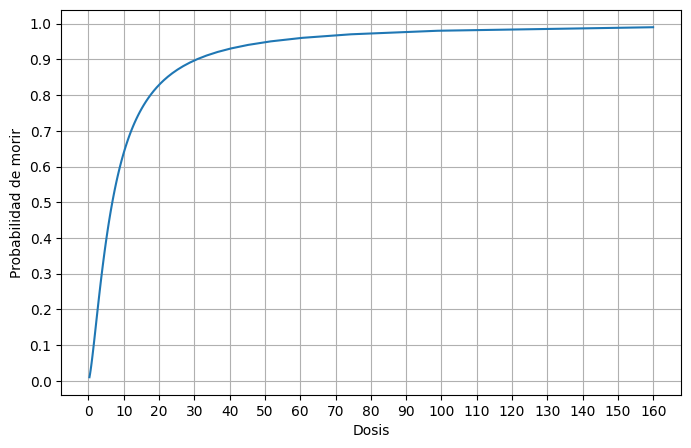

In [ ]:
# rango de probabilidades
prob = np.linspace(0.01,0.99,100)
# dosis
logits = np.log(prob/(1-prob))
dosis_letal = np.exp((logits + 2.7761)/1.4525)
# gráfico
f, ax = plt.subplots(figsize=(8, 5))
ax.plot(dosis_letal,prob)
ax.set_xlabel('Dosis')
ax.set_ylabel('Probabilidad de morir')
ax.set_yticks(np.arange(0.0,1.1,0.1))
ax.set_xticks(np.arange(0,170,10))
ax.grid(True)

In [ ]:
dosis = pd.DataFrame({'prob':prob, 'dosis_letal':dosis_letal})
#garantías de exterminio del 50%
print(dosis[prob>=0.5].iloc[0,:])
#garantías de exterminio del 95%
print(dosis[prob>=0.95].iloc[0,:])

prob           0.504949
dosis_letal    6.854375
Name: 50, dtype: float64
prob            0.950404
dosis_letal    51.639540
Name: 95, dtype: float64


Así, en el gráfico (y en los cálculos previos) podemos ver que para tener unas garantías de exterminio del 50% de la población, habría que aplicar una dosis de 6.85, mientras que habría que elevarla a 51.64 para tener unas garantías de matar al menos al 95% de los insectos.

En este problema no utilizamos las métricas de evaluación de la clasificación, ya que los datos son binomiales, y la respuesta es la proporción de muertos.

## Predicción con Python


Como en los modelos anteriores, la última fase de modelización pasa por predecir los valores de la respuesta para diferentes combinaciones de las predictoras. En este caso se trata de determinar las probabilidades de ocurrencia del suceso de interés, y resolver la clasificación si la respuesta es binaria (no agrupada como en la binomial).

Para ello estableceremos las secuencias de valores sobre los que predecir en cada variable predictora, y con ellas conformaremos el grid de valores con todas las combinaciones posibles (con la función `meshgrid()` de Numpy). A continuación bastará con utilizar el método `get_prediction()` con el modelo ajustado, para obtener las predicciones correspondientes.

El código básico para la predicción es el siguiente:
```
# PREDICCION DE NUEVAS OBSERVACIONES
# Sean x1_pred, x2_pred, ... secuencias de valores a predecir en las variables x1, x2,...
# ya estandarizadas, si procede

# Grid de valores con todas las combinaciones
nrid= len(x1_pred)*len(x2_pred)*... # longitud
grid = np.meshgrid(x1_pred,x2_pred,...)
# se construye un diccionario con el grid y los nombres de las variables en el modelo
grid_dict = dict([('x1', grid[0].reshape(ngrid,)),
  ('x2', grid[1].reshape(ngrid,)),...])

# Se obtiene la predicción
pred = fit.get_prediction(grid_dict).summary_frame(alpha=0.05)

# se almacena la predicción
pred_df= pd.concat([pd.DataFrame(grid_dict),pred],axis=1)
```

Es de importante tener en cuenta que cuando utilizamos la estandarización de los predictores para ajustar el modelo (como en el ejemplo de Kyphosis), los nuevos valores de las variables predictoras habremos de estandarizarlos usando la misma media y desviación típica de los datos con los que resolvimos el ajuste.

### Ejemplo 1. Kyphosis

Para establecer la secuencia de valores en los que obtener las predicciones vamos a seguir los siguientes pasos:
1. Definimos el rango de valores observados en cada uno de los predictores, y definimos una secuencia razonable (de 10 en 10 para `age`, y de 1 en 1 para `number` y `start`).
1. Estandarizamos estas secuencias utilizando la media y desviación típica de los datos observados utilizados en el ajuste.
1. Construimos un grid con todas las combinaciones posibles de estas secuencias, utilizando la función `np.meshgrid()`.
1. Guardamos en un diccionario todos los valores del grid de combinaciones, utilizando los mismos nombres de las variables en el modelo.
1. Predecimos y mostramos los resultados.
1. Finalmente los podemos almacenar en un DataFrame para utilizarlos y representarlos a continuación.


In [ ]:
# 1. Secuencia de valores de las predictoras sobre los que predecir
sec_age = np.arange(Kyphosis['age'].min(), Kyphosis['age'].max(), 10)
sec_number = np.arange(Kyphosis['number'].min(), Kyphosis['number'].max(), 1)
sec_start = np.arange(Kyphosis['start'].min(), Kyphosis['start'].max(), 1)

# 2. Estandarización de las secuencias con los datos observados
est_age = (sec_age - Kyphosis['age'].mean())/Kyphosis['age'].std()
est_number = (sec_number - Kyphosis['number'].mean())/Kyphosis['number'].std()
est_start = (sec_start - Kyphosis['start'].mean())/Kyphosis['start'].std()

# 3. Grid con la combinación de secuencias
ngrid = len(est_age)*len(est_number)*len(est_start)
grid = np.meshgrid(est_age,est_number,est_start)

# 4. Dicionario con el grid
grid_dict = dict([('age_est', grid[0].reshape(ngrid,)),
  ('number_est', grid[1].reshape(ngrid,)),
  ('start_est', grid[2].reshape(ngrid,))])

# 5. Predicción de probabilidades
pred_kyphosis = fit_kyphosis.get_prediction(grid_dict).summary_frame(alpha=0.05)
# Clasificación obtenida de la predicción
pred_kyphosis['kyphosis'] = 1*pred_kyphosis['mean']>0.5

# 6. Almacenamiento del grid (en escala original) y sus predicciones
grid = np.meshgrid(sec_age, sec_number, sec_start)
# Dicionario de combinaciones en la escala original
grid_dict = dict([('age', grid[0].reshape(ngrid,)),
  ('number', grid[1].reshape(ngrid,)),
  ('start', grid[2].reshape(ngrid,))])
pred_df= pd.concat([pd.DataFrame(grid_dict),pred_kyphosis],axis=1)
pred_df.head()

,age,number,start,mean,mean_se,mean_ci_lower,mean_ci_upper,kyphosis
0,1,2,1,0.196027,0.167339,0.029530,0.661448,False
1,1,2,2,0.165506,0.143094,0.025371,0.601766,False
2,1,2,3,0.138915,0.121318,0.021623,0.540782,False
3,1,2,4,0.116003,0.102186,0.018272,0.480572,False
4,1,2,5,0.096446,0.085674,0.015304,0.423002,False


En la columna `mean` tenemos la probabilidad estimada, su desviación típica en `mean_se`, y el intervalo de confianza en las columnas `mean_ci_lower` y `mean_ci_upper`.

Representamos a continuación las curvas de predicción de la probabilidad en función de la edad, para los diferentes niveles de respuesta en las variables `number`(identificada por colores) y `start`(distribuida en facetas/columnas). Tenemos así una predicción completa de la evolución de la probabilidad estimada en función de la edad y el número de vértebras involucradas, para cada vértebra de inicio.

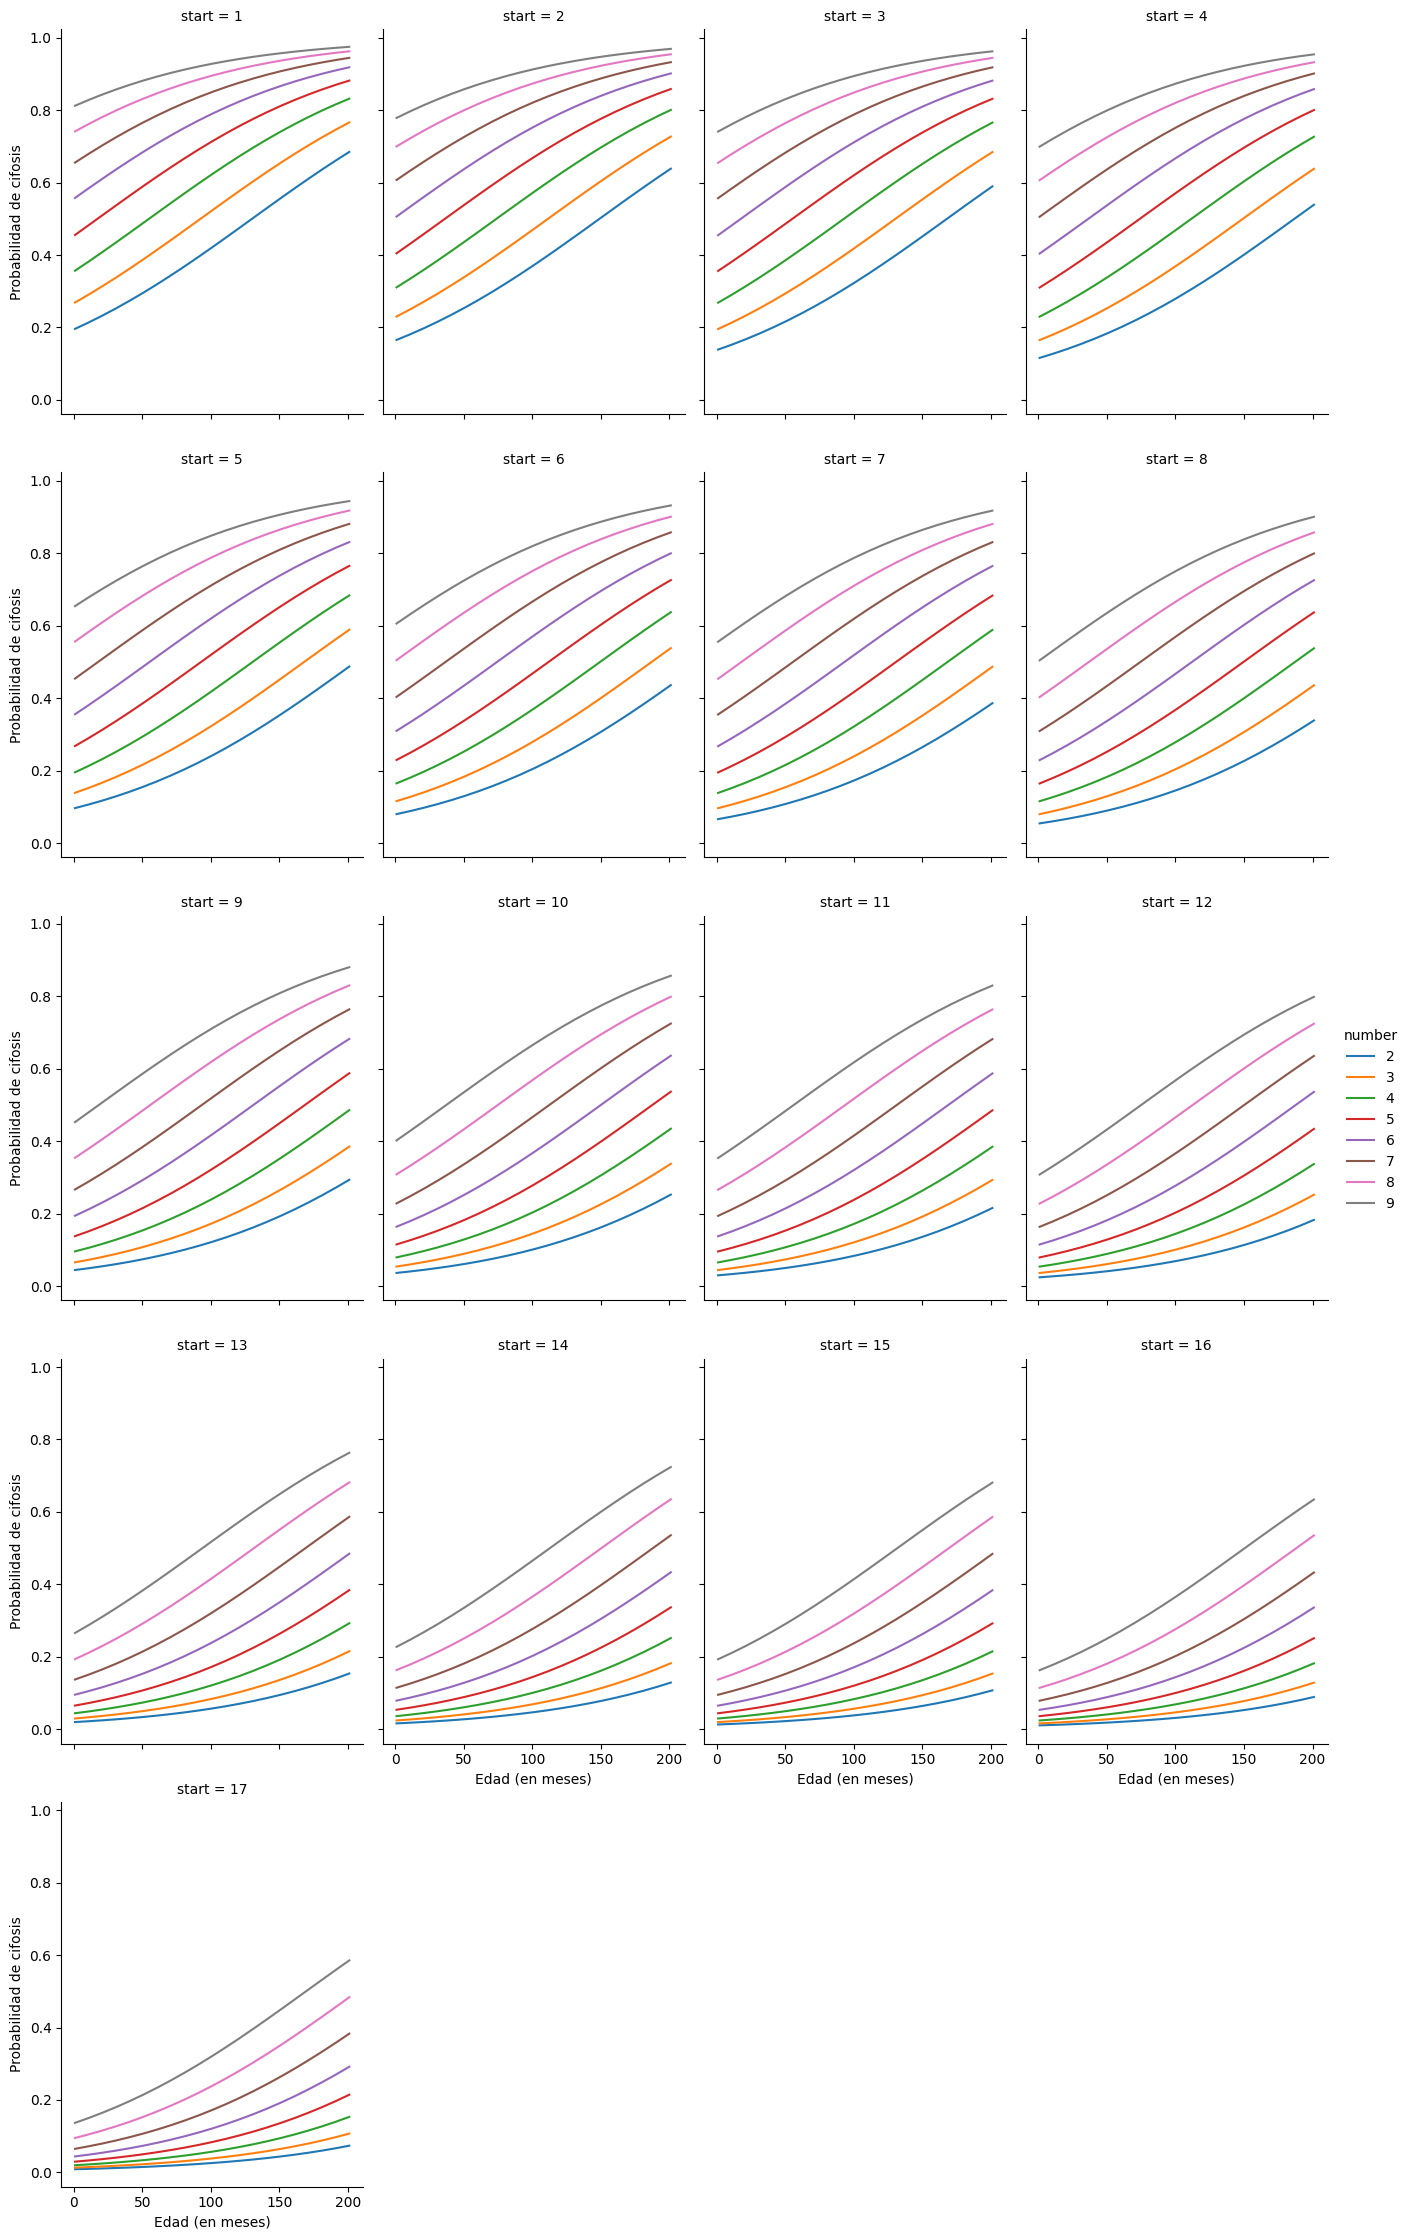

In [ ]:
# Representación de la predicción de nuevas observaciones
g = sns.FacetGrid(pred_df, col="start", col_wrap = 4, hue ="number", height=4.5, aspect=.75)
g.map_dataframe(sns.lineplot, x="age", y="mean")
g.add_legend()
g.set_ylabels("Probabilidad de cifosis")
g.set_xlabels("Edad (en meses)")

En todos los gráficos se observa un comportamiento creciente de la probabilidad de cifosis, y mantenido para el número de vértebras involucradas (todos los colores se presentan en la misma secuencia),  pero es claro que el número de la vértebra de inicio es determinante para la magnitud de esta probabilidad, y se observa que la altura de las curvas desciende cuando se incrementa `start`.

Podemos representar también la clasificación predicha (cifosis/no cifosis), u obtenerla directamente a partir del dataframe.

In [ ]:
# Seleccionamos unos valores en la secuencia de predicción para obtener las predicciones
age_e = 11
number_e = 5
start_e = 5
pred_df[(pred_df.age==age_e) & (pred_df.number==number_e) & (pred_df.start==start_e)]

,age,number,start,mean,mean_se,mean_ci_lower,mean_ci_upper,kyphosis
1092,11,5,5,0.289823,0.123781,0.111557,0.570147,False


### Ejemplo 2. Dosis-respuesta

Obtenemos el grid de predicción, que en este caso es más sencillo al tener solo una predictora, y representamos la solución obtenida.

In [ ]:
# Secuencia de valores de las predictoras consideradas en el modelo
sec_ld = np.linspace(Dosis['logdosis'].min(), Dosis['logdosis'].max(), 200)
# Dicionario para predicciones
grid_dict = dict([('logdosis', sec_ld)])
# Predicción
pred_dosis = fit_dosis.get_prediction(grid_dict).summary_frame(alpha=0.05)
pred_df= pd.concat([pd.DataFrame(grid_dict),pred_dosis],axis=1)
pred_df['dosis'] = np.exp(pred_df['logdosis'])
pred_df.head()

,logdosis,mean,mean_se,mean_ci_lower,mean_ci_upper,dosis
0,0.000000,0.059185,0.092169,0.002447,0.617328,1.000000
1,0.017416,0.060609,0.093539,0.002571,0.617567,1.017568
2,0.034832,0.062065,0.094918,0.002701,0.617817,1.035445
3,0.052247,0.063554,0.096307,0.002838,0.618078,1.053636
4,0.069663,0.065077,0.097704,0.002981,0.618351,1.072147


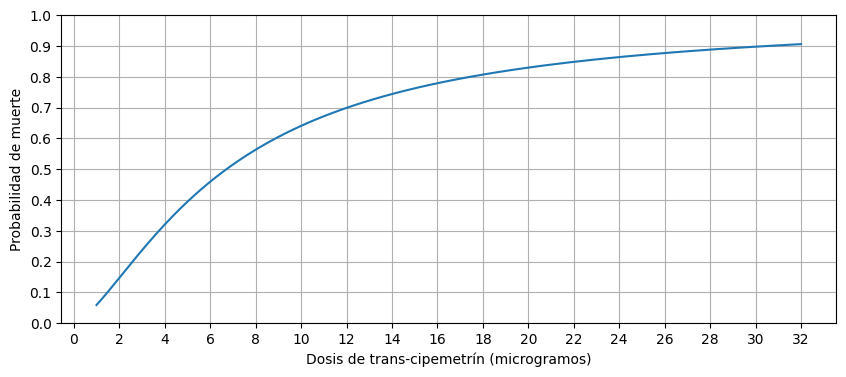

In [ ]:
# REPRESENTACIÓN DE LA PREDICCIÓN
f, ax = plt.subplots(figsize=(10, 4))
sns.lineplot(pred_df, x="dosis",y="mean")
ax.grid(True)
ax.set_ylabel("Probabilidad de muerte")
ax.set_xlabel("Dosis de trans-cipemetrín (microgramos)")
ax.set_yticks(np.arange(0.0,1.1,0.1))
ax.set_xticks(np.arange(0,34,2))
plt.show()

# <font color="steelblue">4. Ejercicios</font>

* **Ejercicio 1**. En un experimento se sometió a cierto número de cucarachas (`number`) a cinco horas de exposición a disulfato de carbono gaseoso a varias concentraciones. Se pretendía investigar la relación existente entre la dosis (`dose`) de disulfato administrada y la resistencia de los insectos (`dead`); si existe tal relación, interesa determinar la dosis a la cual es posible garantizar el exterminio del 50% de los insectos.

In [ ]:
ejer01 = pd.read_csv('https://goo.gl/E2MlSZ')

* **Ejercicio 2**. Se realiza un experimento in vitro para estimar el número de anteras embriogénicas de las especies de plantas Datura innoxia Mill bajo dos condiciones experimentales. El primer tratamiento consiste en almacenar a 3° C durante 48 horas, y el segundo consiste en un control donde no se aplica ningún tratamiento. Además se considera una variable que representa los tres valores de fuerza de centrifugación. Las variables registradas son `total`, `embryogenic`, `storage`, `centrifuge`. Es de interés en el análisis investigar si efectivamente se demostraba variación en el número de anteras por el tratamiento.

In [ ]:
ejer02 = pd.read_csv('https://goo.gl/6P3zRr')

* **Ejercicio 3**. Se realiza un ensayo clínico para determinar en un grupo de personas mayores su estado psiquiátrico. Para cada sujeto se realiza un análisis completo y se clasifica cada uno en función de si muestra rasgos de senilidad (`senility`) -calificados como 1, o 0 si no los hay). Por otro lado se les pasa el test de escala de inteligencia de adultos (`score`) para saber si la puntuación obtenida puede estar relacionada con que la persona tenga rasgos de senilidad o no.

In [ ]:
ejer03 = pd.read_csv('https://goo.gl/6E8fhd')

* **Ejercicio 4**. Se realiza un estudio para investigar el impacto de la bomba de Hiroshima en la aparición de casos de leucemia. Para ello se registró, para todos los sujetos que presentaron algún tipo de cáncer, el grado de radiación que mantenía la persona. Las variables que aparecen son los conteos del número de casos de leucemia (`leukemia`) y de otros tipos de cáncer (`other`) para los diferentes niveles de radiación (`radiation`). Se contabilizan también el número total de casos de cáncer registrados (`total`). Es de interés en el análisis investigar la influencia del grado de radiación en la aparición de un mayor número de casos de leucemia.

In [ ]:
ejer04 = pd.read_csv('https://goo.gl/ZDIWVC')

* **Ejercicio 5**. Los datos siguientes describen los patrones de comportamiento en el consumo de drogas psicotrópicas en una muestra de individuos del Oeste de Londres. Los investigadores se plantean las preguntas siguientes:

  * ¿Hay diferencias por `sexo` en el consumo de drogas? ¿Cómo influye la `edad` para explicar el consumo de psicotrópicos? ¿La edad influye igual en hombres y en mujeres?
  * Obtener la expresión y el valor de las predicciones sobre el consumo de psicotrópicos en hombres y en mujeres de 17 y 52 años con el modelo ajustado.

  Las variables `usa` y `nousa` contienen la información sobre el uso de drogas psicotrópicas.

In [ ]:
sexo = ["H", "H", "H", "H", "M", "M", "M", "M"]
edad = ["16-29","30-44","45-64","65-74","16-29","30-44","45-64","65-74"]
usa = [21,32,70,43,46,89,169,51]
nousa = [683,596,705,295,738,700,847,196]

ejer05 = pd.DataFrame({"sexo": sexo, "edad": edad, "usa": usa, "nousa": nousa})

* **Ejercicio 6**. En el Hospital de Yale-New Heaven, en Connecticut, se llevó a cabo un estudio para investigar la relación entre los nacimientos prematuros (el niño nazca antes de 37 semanas de gestación o su peso sea inferior a 2500 g.) y la edad de la madre. La población de estudio consistió en 175 madres de niños nacidos únicos y prematuros, y 303 madres de niños no prematuros. Los datos agrupados en función de la edad de la madre se presentan a continuación. ¿Hay alguna relación entre la edad de la madre y el hecho de que un niño nazca prematuro? ¿Cuál es el grupo de edad con mayor riesgo?

In [ ]:
edad =["14-17","18-19","20-24","25-29","+30"]
casos = [15,22,47,56,35]
controles = [16,25,62,122,18]

ejer06 = pd.DataFrame({"edad": edad, "casos": casos, "controles": controles})

* **Ejercicio 7**. El agua potable es el derecho humano básico y un factor importante para la salud. El conjunto de datos `Water potability`, tiene por objetivo estudiar la potabilidad del agua utilizando varias propiedades químicas, debido a su importancia como cuestión de salud y desarrollo a nivel nacional, regional y local. En algunas regiones, se ha demostrado que las inversiones en abastecimiento de agua y saneamiento pueden producir un beneficio económico neto, ya que la reducción de los efectos adversos para la salud y los costes de la atención sanitaria superan los costes de las intervenciones. Las variables consideradas son:

  * **pH**: valor del pH.
  * **Hardness**: dureza o capacidad del agua para precipitar el jabón causado por el calcio y el magnesio.
  * **Solids**: sólidos disueltos totales (en partes por millón)
  * **Chloramines**: cantidad de cloraminas (en partes por millón)
  * **Sulfate**: cantidad de sulfatos disueltos (en mg/L)
  * **Conductivity**: conductividad eléctrica del agua (en μS/cm)
  * **Organic_carbon**: cantidad de carbono orgánico (en partes por millón)
  * **Trihalomethanes**: cantidad de trihalometanos (en μg/L)
  * **Turbidity**: medida de la propiedad de emisión de luz del agua en NTU.
  * **Potability**: indica si el agua es segura para el consumo humano (1 = potable y 0 = no potable)

In [ ]:
ejer07 = pd.read_csv('https://raw.githubusercontent.com/ia4legos/MachineLearning/main/data/water_potability.csv')

* **Ejercicio 8**. En este conjunto de datos se recoge información sobre los abulones, de la familia de los moluscos. Se está interesado en medir su desarrollo, que viene determinado principalmente por su desarrollo sexual. Concretamente se consideran tres estados de desarrollo asociados con la variable `Sex`: `M` (machos), `F` (hembras), e `I` (infantil o sin desarrollo sexual). Para clasificar cada sujeto se utiliza el conjunto de variables que son de tipo numérico. La edad del abulón se determina cortando la cáscara a través del cono, tintándola y contando el número de anillos mediante un microscopio (una tarea tediosa que consume mucho tiempo). Las variables consideradas son:

  * **Sex**: sexo (M = masculino, F = femenino e I = intantil)
  * **Length**: longitud de la carcasa más larga (en mm)
  * **Diameter**: diámetro perpendicular a la longitud (en mm)
  * **Height**: altura con carne en cáscara (en mm)
  * **Whole weight**: peso completo (en gramos)
  * **Shucked weight**: peso de la carne (en gramos)
  * **Viscera weight**: peso de las vísceras después del sangrado (en gramos)
  * **Shell weight**: peso de la cáscara después de secarse (en gramos)
  * **Rings**: anillos (+1,5 da la edad en años)

In [ ]:
ejer08 = pd.read_csv('https://www.kaggle.com/datasets/rodolfomendes/abalone-dataset')